# Pólya-Gamma Model Backend Profiling: numpy vs JAX (sparse)

This notebook re-profiles the Pólya-Gamma spatial models — **SAR-logit** and the
**structural SAR negative binomial** — across the two Gibbs execution backends,
now that the JAX path is **fully sparse**:

- **`numpy`** — CHOLMOD sparse Cholesky (`sksparse`) for the augmented β/η block,
  numpy PG draws, and a numpy log-determinant callable. The long-standing default.
- **`jax`** — a single `@jax.jit` Gibbs loop using **`cholmod_jax`** (cholgraph,
  JAX-native sparse CHOLMOD) for the β/η solve, **BCOO** sparse `W` matvecs (the
  matrix is never densified), and a JAX-native differentiable log-determinant.

## The two W regimes (this is the important axis)

The augmented β/η precision `AᵀΩA + prior` is symmetric SPD for **any** `W`, so the
*solve* is a Cholesky either way. The backend split that actually matters is the
**log-determinant** `log|I − ρW|`, and it hinges on whether `W` is
**D-symmetrizable**, not on whether the matrix is literally symmetric:

- **Symmetric adjacency → row-standardized** (rook/queen contiguity): `W = D⁻¹A`
  with `A` symmetric, so `W` *is* D-symmetrizable even though the row-standardized
  matrix is not literally symmetric. → exact **Cholesky** logdet
  (`cheb_cholesky` / `cholmod`).
- **Asymmetric adjacency → row-standardized** (directed KNN, travel time, migration):
  the underlying adjacency is not symmetric, so `W` is **not** D-symmetrizable and a
  Cholesky logdet does not exist. → exact **LU** logdet (`aaa`, KLU-seeded).

Both logdet methods are **exact** (machine precision); they differ only in the
factorization the matrix admits. `max|W − Wᵀ|` is *not* the discriminator — a
row-standardized rook `W` and a row-standardized KNN `W` can have identical raw
asymmetry while landing on different logdet paths. We therefore key on the
**auto-resolved logdet method** reported by the model.

## Question

With the sparse JAX path in place, does `jax` now beat `numpy` on CPU, and at what
`n`? Both models currently register `auto_backend="numpy"`; this benchmark is the
evidence for whether that default should flip.


In [2]:
import time
import warnings
from dataclasses import dataclass

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from libpysal import graph

from neighbayes import dgp
from neighbayes.models import SARLogit, SARNegBin

warnings.filterwarnings("ignore")

In [3]:
def build_w(gdf, kind: str, k: int = 6):
    """Row-standardized W. ``kind="sym"`` = rook contiguity (D-symmetrizable →
    Cholesky logdet); ``kind="asym"`` = directed KNN on centroids
    (non-D-symmetrizable → LU/aaa logdet)."""
    if kind == "sym":
        return graph.Graph.build_contiguity(gdf, rook=True).transform("r")
    pts = gdf.copy()
    pts["geometry"] = gdf.geometry.centroid
    return graph.Graph.build_knn(pts, k=k).transform("r")


def make_dataset(model: str, n_side: int, kind: str, seed: int = 2026):
    """Simulate one PG dataset on an ``n_side × n_side`` grid with the chosen W."""
    gdf = dgp.simulate_sar(n=n_side, create_gdf=True, seed=seed)
    W = build_w(gdf, kind)
    sim = (dgp.simulate_sar_logit if model == "logit" else dgp.simulate_sar_negbin)(
        W=W, gdf=gdf, rho=0.4, seed=seed
    )
    y = sim["y"].to_numpy() if hasattr(sim["y"], "to_numpy") else np.asarray(sim["y"])
    X_cols = [c for c in sim.columns if c.startswith("X_")]
    X = sim[X_cols].to_numpy()
    return y, X, W


def fit_and_time(model: str, y, X, W, backend: str, draws, tune, chains, seed=2026):
    """Fit one PG model on one backend; return timing + ESS + resolved logdet method."""
    Model = SARLogit if model == "logit" else SARNegBin
    m = Model(y=y, X=X, W=W)
    t0 = time.perf_counter()
    idata = m.fit(
        draws=draws,
        tune=tune,
        chains=chains,
        random_seed=seed,
        progressbar=False,
        gibbs_backend=backend,
        sampler="gibbs",
    )
    elapsed = time.perf_counter() - t0
    ess = float(az.summary(idata, var_names=["rho"]).loc["rho", "ess_bulk"])
    rho_hat = float(idata.posterior["rho"].mean())
    return {
        "total_s": elapsed,
        "ess_rho": ess,
        "ess_per_s": ess / elapsed,
        "rho_hat": rho_hat,
        "logdet_method": m._resolved_logdet_method,
    }

In [4]:
@dataclass
class Config:
    # grid sides -> obs = side²: 20→400, 30→900, 45→2025, 71→5041 (≥5000)
    sides: tuple = (20, 30, 45, 71)
    models: tuple = ("logit", "nb")
    w_kinds: tuple = ("sym", "asym")
    backends: tuple = ("numpy", "jax")
    draws: int = 400
    tune: int = 400
    chains: int = 2
    seed: int = 2026


cfg = Config()
rows = []
for side in cfg.sides:
    n = side * side
    for model in cfg.models:
        for kind in cfg.w_kinds:
            y, X, W = make_dataset(model, side, kind, seed=cfg.seed)
            for backend in cfg.backends:
                print(
                    f"n={n:5d} | {model:5s} | W={kind:4s} | backend={backend} ...",
                    flush=True,
                )
                try:
                    r = fit_and_time(
                        model,
                        y,
                        X,
                        W,
                        backend,
                        cfg.draws,
                        cfg.tune,
                        cfg.chains,
                        cfg.seed,
                    )
                    r.update(n_obs=n, model=model, w_kind=kind, backend=backend)
                    rows.append(r)
                except Exception as exc:  # keep the sweep going
                    print(f"    FAILED: {type(exc).__name__}: {exc}")

res = pd.DataFrame(rows)
res

n=  400 | logit | W=sym  | backend=numpy ...
n=  400 | logit | W=sym  | backend=jax ...
n=  400 | logit | W=asym | backend=numpy ...
n=  400 | logit | W=asym | backend=jax ...
n=  400 | nb    | W=sym  | backend=numpy ...
n=  400 | nb    | W=sym  | backend=jax ...
n=  400 | nb    | W=asym | backend=numpy ...
n=  400 | nb    | W=asym | backend=jax ...
n=  900 | logit | W=sym  | backend=numpy ...
n=  900 | logit | W=sym  | backend=jax ...
n=  900 | logit | W=asym | backend=numpy ...
n=  900 | logit | W=asym | backend=jax ...
n=  900 | nb    | W=sym  | backend=numpy ...
n=  900 | nb    | W=sym  | backend=jax ...
n=  900 | nb    | W=asym | backend=numpy ...
n=  900 | nb    | W=asym | backend=jax ...
n= 2025 | logit | W=sym  | backend=numpy ...
n= 2025 | logit | W=sym  | backend=jax ...
n= 2025 | logit | W=asym | backend=numpy ...
n= 2025 | logit | W=asym | backend=jax ...
n= 2025 | nb    | W=sym  | backend=numpy ...
n= 2025 | nb    | W=sym  | backend=jax ...
n= 2025 | nb    | W=asym | backe

,total_s,ess_rho,ess_per_s,rho_hat,logdet_method,n_obs,model,w_kind,backend
0,3.891946,566.0,145.428534,0.414205,eigenvalue,400,logit,sym,numpy
1,2.005337,357.0,178.024981,0.406338,eigenvalue,400,logit,sym,jax
2,10.399885,614.0,59.039116,0.203081,eigenvalue,400,logit,asym,numpy
3,1.735760,272.0,156.703733,0.220011,eigenvalue,400,logit,asym,jax
4,4.210539,465.0,110.437171,0.314286,eigenvalue,400,nb,sym,numpy
5,2.431107,442.0,181.810158,0.306681,eigenvalue,400,nb,sym,jax
6,5.301474,504.0,95.067908,0.224811,eigenvalue,400,nb,asym,numpy
7,2.467875,494.0,200.172230,0.219375,eigenvalue,400,nb,asym,jax
8,5.228508,643.0,122.979643,0.372124,cheb_cholesky,900,logit,sym,numpy
9,2.109728,522.0,247.425202,0.370469,cheb_cholesky,900,logit,sym,jax


In [5]:
# Confirm the two W regimes land on the two exact logdet methods.
if not res.empty:
    method_map = (
        res.groupby(["w_kind"])["logdet_method"].unique().apply(sorted).to_dict()
    )
    print("Resolved logdet method by W regime:")
    for kind, methods in method_map.items():
        print(f"  W={kind:4s} -> {methods}")
    display(
        res.pivot_table(
            index=["model", "n_obs"], columns=["w_kind", "backend"], values="total_s"
        ).round(2)
    )

Resolved logdet method by W regime:
  W=asym -> ['aaa', 'eigenvalue']
  W=sym  -> ['cheb_cholesky', 'eigenvalue']


w_kind        asym           sym       
backend        jax  numpy    jax  numpy
model n_obs                            
logit 400     1.74  10.40   2.01   3.89
      900     2.39  18.79   2.11   5.23
      2025    5.29  23.45   3.77   8.04
      5041   16.73  27.97  10.43  22.27
nb    400     2.47   5.30   2.43   4.21
      900     3.01   6.45   2.80   5.24
      2025    6.96  10.60   4.78   8.68
      5041   17.23  24.70  10.93  24.20

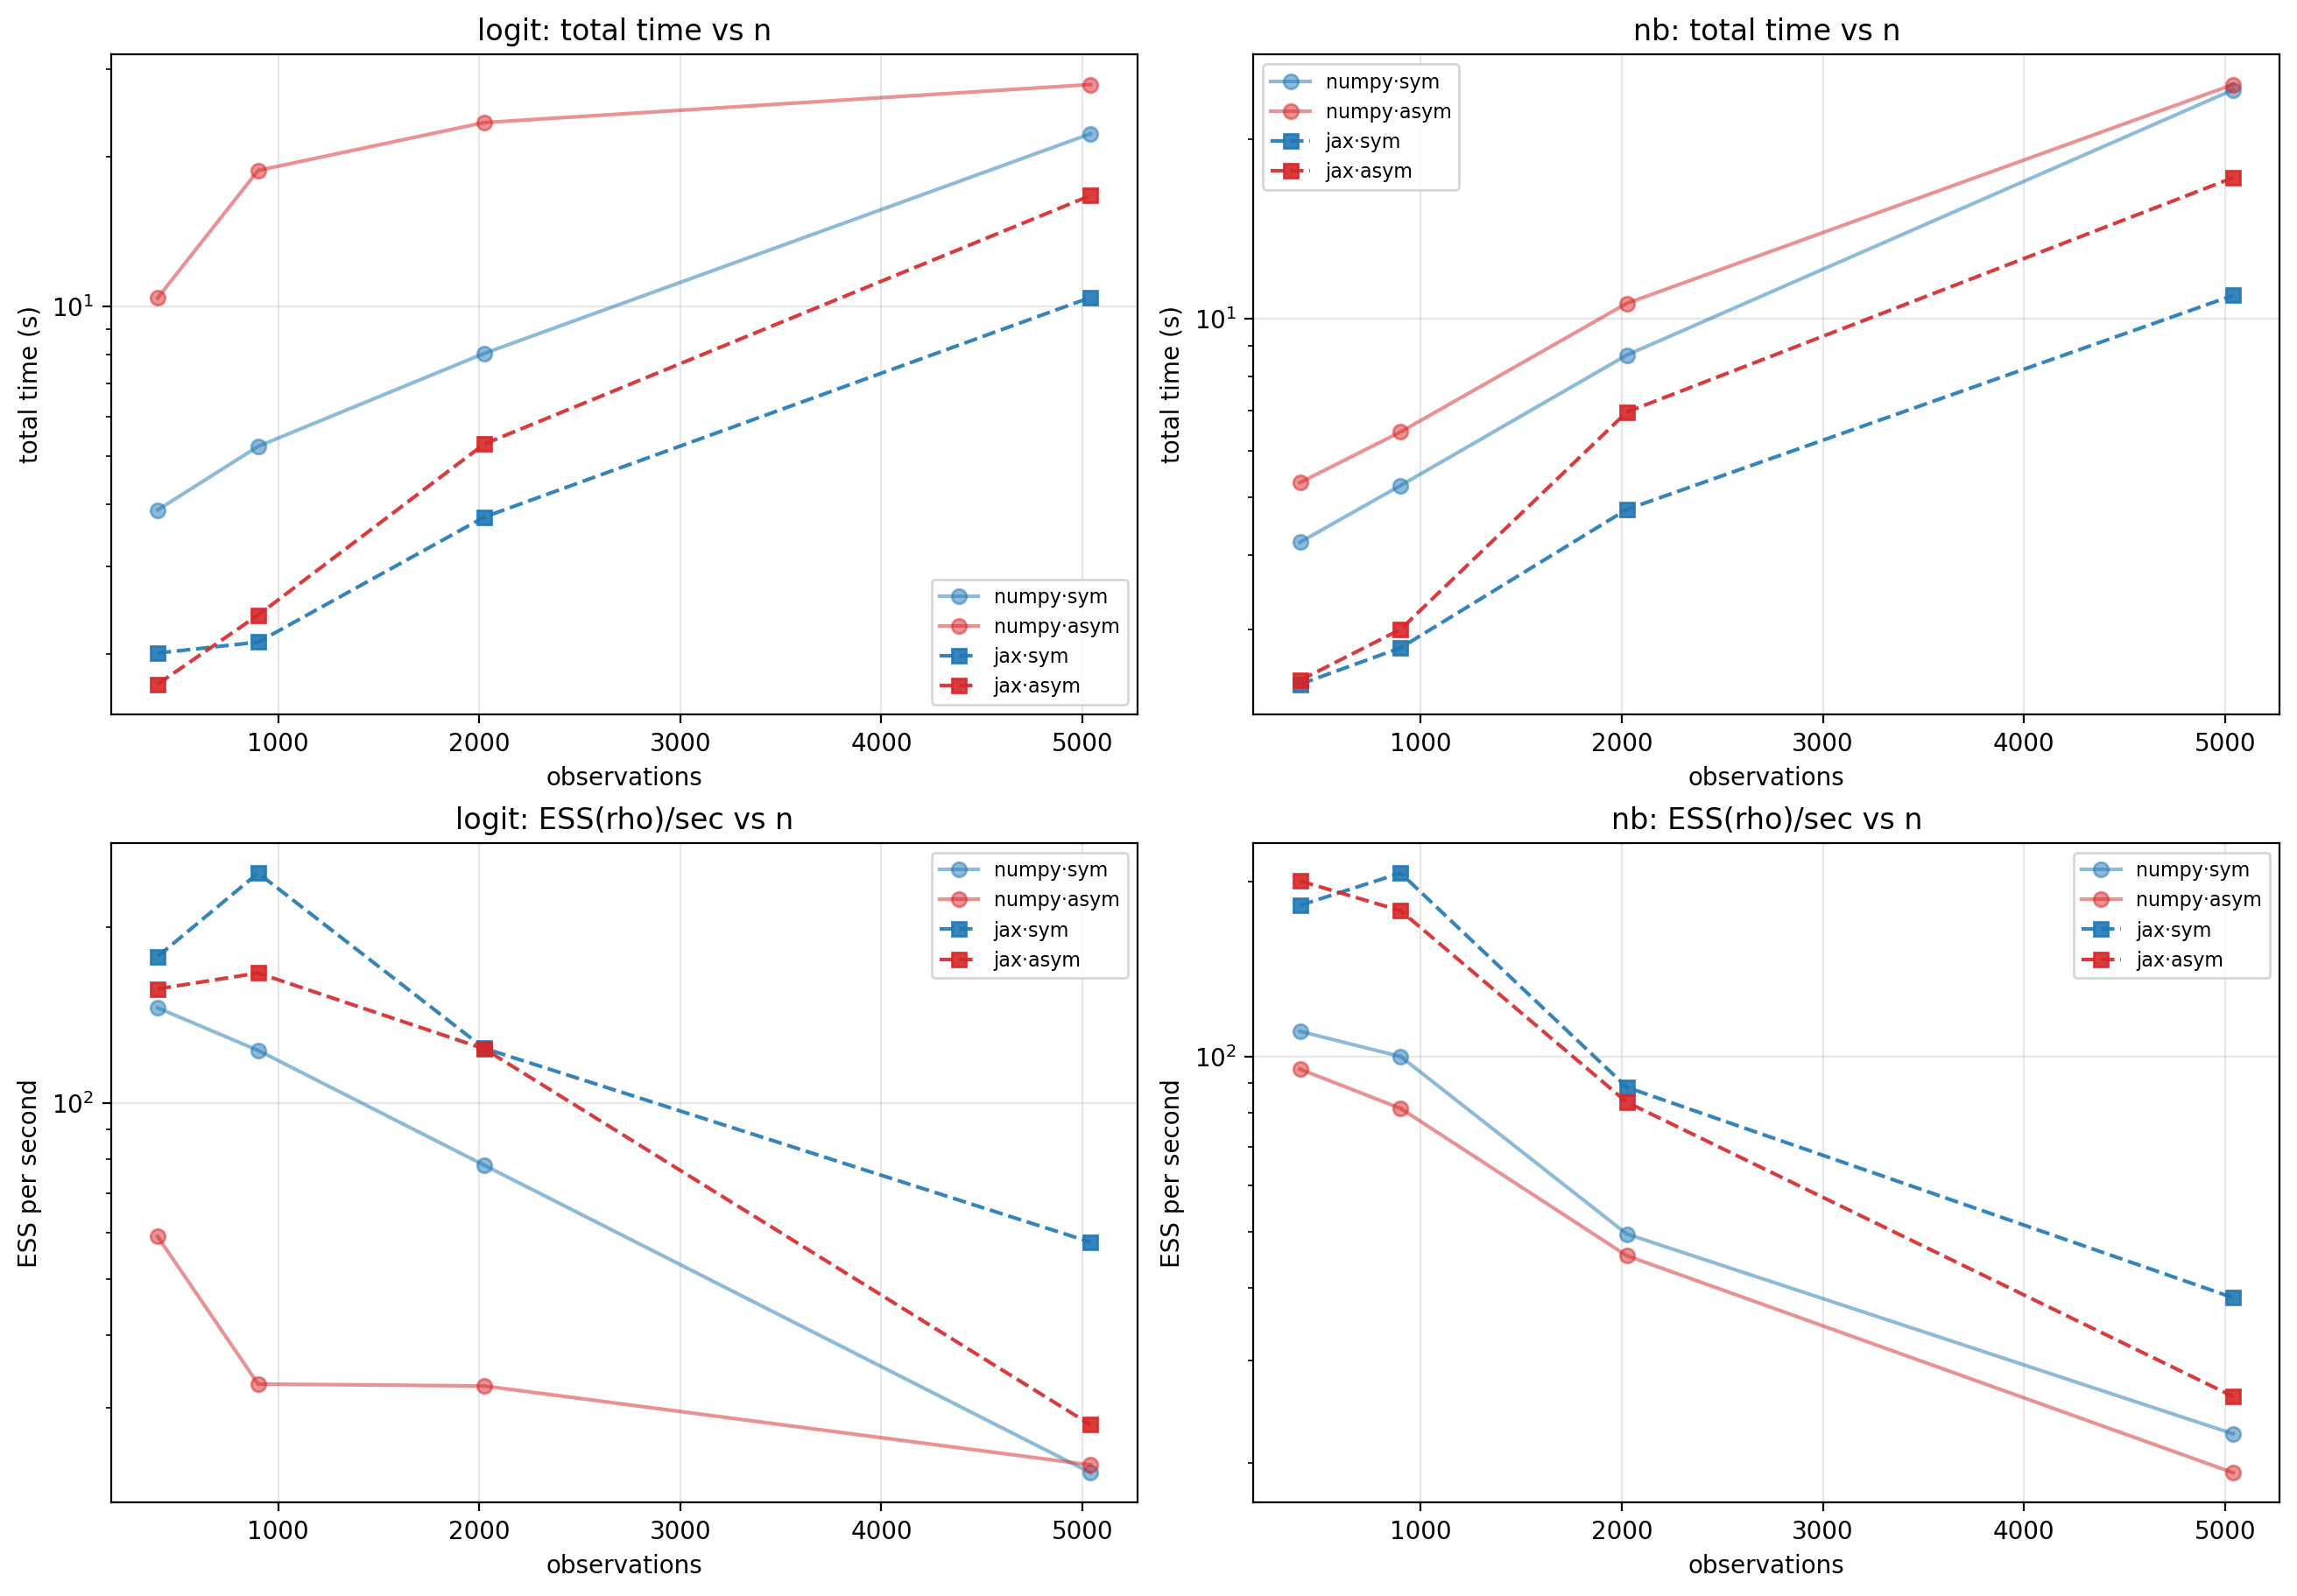

In [6]:
if not res.empty:
    fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
    styles = {"numpy": dict(marker="o", ls="-"), "jax": dict(marker="s", ls="--")}
    colors = {"sym": "#1f77b4", "asym": "#d62728"}
    for j, model in enumerate(("logit", "nb")):
        for backend in cfg.backends:
            for kind in cfg.w_kinds:
                sub = res[
                    (res.model == model)
                    & (res.backend == backend)
                    & (res.w_kind == kind)
                ].sort_values("n_obs")
                if sub.empty:
                    continue
                lbl = f"{backend}·{kind}"
                axes[0, j].plot(
                    sub.n_obs,
                    sub.total_s,
                    color=colors[kind],
                    alpha=0.9 if backend == "jax" else 0.5,
                    label=lbl,
                    **styles[backend],
                )
                axes[1, j].plot(
                    sub.n_obs,
                    sub.ess_per_s,
                    color=colors[kind],
                    alpha=0.9 if backend == "jax" else 0.5,
                    label=lbl,
                    **styles[backend],
                )
        axes[0, j].set(
            title=f"{model}: total time vs n",
            xlabel="observations",
            ylabel="total time (s)",
            yscale="log",
        )
        axes[1, j].set(
            title=f"{model}: ESS(rho)/sec vs n",
            xlabel="observations",
            ylabel="ESS per second",
            yscale="log",
        )
        for ax in (axes[0, j], axes[1, j]):
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8)
    plt.show()

In [7]:
# Correctness: numpy and jax must agree (within MC noise) on the posterior.
# Deterministic side-check of the JAX exact logdet is in logdet_profiling.ipynb;
# here we confirm the end-to-end samplers agree on rho.
if not res.empty:
    agree = res.pivot_table(
        index=["model", "w_kind", "n_obs"], columns="backend", values="rho_hat"
    ).dropna()
    agree["abs_diff"] = (agree["numpy"] - agree["jax"]).abs()
    print("Posterior mean rho: numpy vs jax (should agree within MC noise)")
    display(agree.round(3))

Posterior mean rho: numpy vs jax (should agree within MC noise)


backend               jax  numpy  abs_diff
model w_kind n_obs                        
logit asym   400    0.220  0.203     0.017
             900    0.366  0.359     0.008
             2025   0.327  0.327     0.000
             5041   0.296  0.298     0.002
      sym    400    0.406  0.414     0.008
             900    0.370  0.372     0.002
             2025   0.335  0.326     0.008
             5041   0.375  0.374     0.001
nb    asym   400    0.219  0.225     0.005
             900    0.341  0.338     0.003
             2025   0.400  0.402     0.001
             5041   0.371  0.370     0.001
      sym    400    0.307  0.314     0.008
             900    0.320  0.316     0.004
             2025   0.368  0.370     0.002
             5041   0.385  0.389     0.004

## Reading the results

- **Two exact logdet paths, auto-selected by W regime.** The `sym` (rook) datasets
  resolve to the Cholesky logdet; the `asym` (directed KNN) datasets resolve to the
  LU-based `aaa` logdet. Both are exact — the split is which factorization `W`
  admits, driven by D-symmetrizability, not raw matrix asymmetry.
- **Backend crossover.** `numpy`/CHOLMOD historically won on CPU at small–moderate
  `n` (dispatch-free per-iteration factorization). The fully-sparse `jax` path pays a
  one-time JIT-compile cost (folded into total time here) but then runs a single
  fused kernel per sweep; its advantage grows with `n`. The crossover point is the
  practically important number.
- **`ess_per_s`** is the fair summary — it nets out any per-iteration cost
  differences and answers "which backend gives more effective draws per wall-second."
- **Same posterior.** numpy and jax use different RNG streams, so exact agreement is
  not expected, but the `rho` posterior means should match within Monte Carlo noise.
- **`auto_backend` policy.** Both PG models register `auto_backend="numpy"`. If `jax`
  wins on `ess_per_s` above some `n`, the auto-selector should prefer `jax` beyond
  that threshold (mirroring the size-based logdet auto-selection).

**Caveats.** Single-run wall-clock at benchmark sizes; NUTS-free Gibbs so timings are
dominated by the per-sweep linear algebra. The JAX total time includes compilation —
amortized away across longer chains than the modest draws used here.
